# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


In [8]:
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nChurn rate: {y_train.mean() * 100:.2f}%")
# ~9.7% churn — heavily imbalanced, so we use class_weight='balanced'

Class distribution in training set:
0    9901
1    1053
Name: churn, dtype: int64

Churn rate: 9.61%


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [9]:
# Add model training in here!
model = RandomForestClassifier(
    n_estimators=500,        # number of trees — more = more stable, diminishing returns after ~300
    max_depth=10,            # limits tree depth to prevent overfitting
    min_samples_split=10,    # a node must have 10+ samples to be split further
    min_samples_leaf=4,      # each leaf must have at least 4 samples
    max_features='sqrt',     # each tree sees sqrt(n_features) — standard for classification
    class_weight='balanced', # corrects for the ~90/10 class imbalance automatically
    random_state=42,
    n_jobs=-1                # use all CPU cores for faster training
)

model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features used: {X_train.shape[1]}")

Model trained successfully!
Number of trees: 500
Number of features used: 61


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [10]:
# Generate predictions here!
# Predicted class labels (0 or 1)
y_pred = model.predict(X_test)

# Predicted probabilities — needed for ROC-AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn (class=1)

print(f"Predictions generated for {len(y_pred)} test samples")
print(f"Predicted churn rate: {y_pred.mean() * 100:.2f}%")
print(f"Actual churn rate:    {y_test.mean() * 100:.2f}%")

Predictions generated for 3652 test samples
Predicted churn rate: 12.84%
Actual churn rate:    10.02%


In [11]:
# Calculate performance metrics here!
print("=" * 55)
print("         RANDOM FOREST — MODEL EVALUATION")
print("=" * 55)

accuracy  = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall    = metrics.recall_score(y_test, y_pred)
f1        = metrics.f1_score(y_test, y_pred)
roc_auc   = metrics.roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy  : {accuracy:.4f}  — % of all predictions correct")
print(f"Precision : {precision:.4f}  — of predicted churners, how many actually churned")
print(f"Recall    : {recall:.4f}  — of actual churners, how many we caught")
print(f"F1 Score  : {f1:.4f}  — harmonic mean of precision & recall")
print(f"ROC-AUC   : {roc_auc:.4f}  — overall ability to separate churners from non-churners")
print()

# Confusion matrix
print("Confusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred))
print()
print(metrics.classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

         RANDOM FOREST — MODEL EVALUATION
Accuracy  : 0.8256  — % of all predictions correct
Precision : 0.2111  — of predicted churners, how many actually churned
Recall    : 0.2705  — of actual churners, how many we caught
F1 Score  : 0.2371  — harmonic mean of precision & recall
ROC-AUC   : 0.6498  — overall ability to separate churners from non-churners

Confusion Matrix:
[[2916  370]
 [ 267   99]]

              precision    recall  f1-score   support

    No Churn       0.92      0.89      0.90      3286
       Churn       0.21      0.27      0.24       366

    accuracy                           0.83      3652
   macro avg       0.56      0.58      0.57      3652
weighted avg       0.85      0.83      0.83      3652



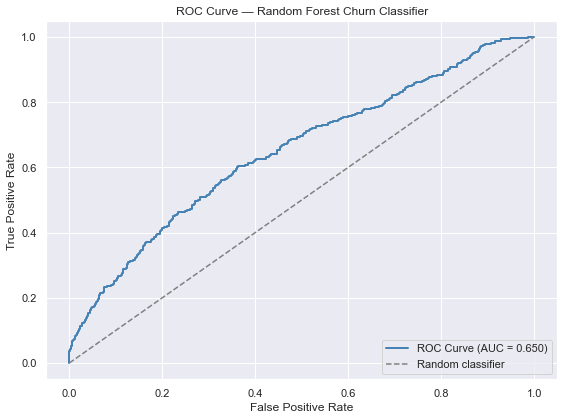

In [12]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Churn Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Top 15 most important features:
                                   feature  importance
                        margin_net_pow_ele    0.072736
                      margin_gross_pow_ele    0.069149
                                  cons_12m    0.050855
                              months_activ    0.042350
                   forecast_meter_rent_12m    0.040355
                           cons_last_month    0.039532
                                net_margin    0.036843
                         forecast_cons_12m    0.032198
                         months_modif_prod    0.031980
               off_peak_peak_var_mean_diff    0.028215
                                   pow_max    0.026756
           off_peak_mid_peak_var_mean_diff    0.025950
           offpeak_diff_dec_january_energy    0.025716
                   var_year_price_off_peak    0.023851
origin_up_lxidpiddsbxsbosboudacockeimpuepw    0.023417


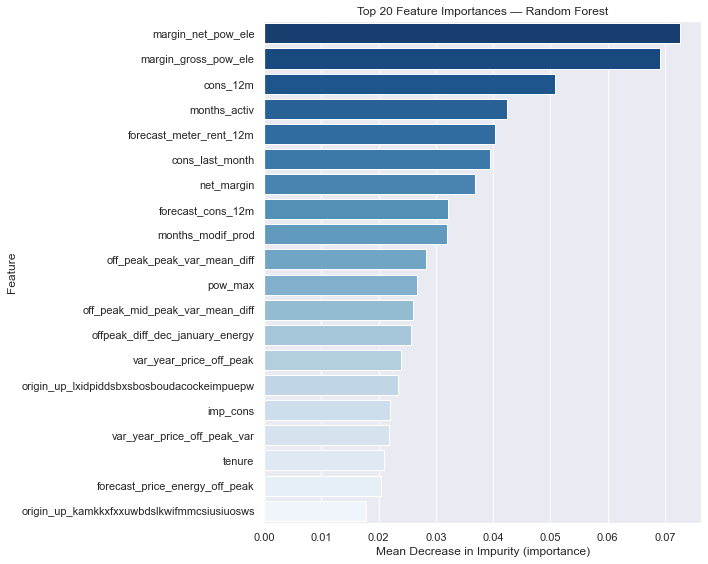

In [13]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 15 most important features:")
print(feature_importance.head(15).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(10, 8))
top20 = feature_importance.head(20)
sns.barplot(
    data=top20,
    x='importance',
    y='feature',
    palette='Blues_r'
)
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity (importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Default threshold : 0.50
Optimal threshold : 0.4580

--- RESULTS AFTER THRESHOLD TUNING ---
Accuracy  : 0.7894
Precision : 0.2015
Recall    : 0.3716
F1 Score  : 0.2613
ROC-AUC   : 0.6498

              precision    recall  f1-score   support

    No Churn       0.92      0.84      0.88      3286
       Churn       0.20      0.37      0.26       366

    accuracy                           0.79      3652
   macro avg       0.56      0.60      0.57      3652
weighted avg       0.85      0.79      0.82      3652



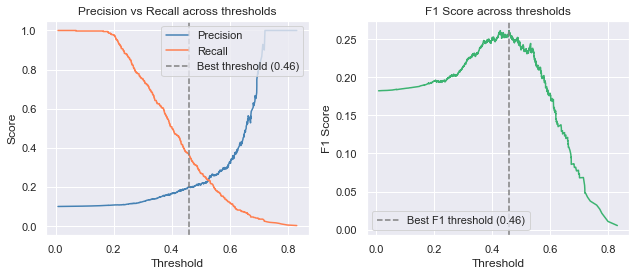

In [14]:
from sklearn.metrics import precision_recall_curve

# Find the best threshold by maximising F1 on the test set
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Default threshold : 0.50")
print(f"Optimal threshold : {best_threshold:.4f}")

# Re-apply predictions using the new threshold
y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)

print("\n--- RESULTS AFTER THRESHOLD TUNING ---")
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score  : {metrics.f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_pred_proba):.4f}") # unchanged — threshold doesn't affect AUC
print()
print(metrics.classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))

# Plot precision-recall tradeoff across thresholds
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='coral')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Best threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall across thresholds')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores[:-1], color='mediumseagreen')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Best F1 threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score across thresholds')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training set only — NEVER to the test set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  No Churn: {(y_train == 0).sum()}  |  Churn: {(y_train == 1).sum()}")
print("After SMOTE:")
print(f"  No Churn: {(y_train_smote == 0).sum()}  |  Churn: {(y_train_smote == 1).sum()}")

# Train a fresh model on the SMOTE-resampled data
model_smote = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
    # Note: class_weight is removed here because SMOTE already balances the classes
)
model_smote.fit(X_train_smote, y_train_smote)

# Evaluate
y_pred_smote       = model_smote.predict(X_test)
y_pred_smote_proba = model_smote.predict_proba(X_test)[:, 1]

print("\n--- RESULTS AFTER SMOTE ---")
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score  : {metrics.f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_pred_smote_proba):.4f}")
print()
print(metrics.classification_report(y_test, y_pred_smote, target_names=["No Churn", "Churn"]))

Before SMOTE:
  No Churn: 9901  |  Churn: 1053
After SMOTE:
  No Churn: 9901  |  Churn: 9901

--- RESULTS AFTER SMOTE ---
Accuracy  : 0.8508
Precision : 0.2122
Recall    : 0.1803
F1 Score  : 0.1950
ROC-AUC   : 0.6219

              precision    recall  f1-score   support

    No Churn       0.91      0.93      0.92      3286
       Churn       0.21      0.18      0.19       366

    accuracy                           0.85      3652
   macro avg       0.56      0.55      0.56      3652
weighted avg       0.84      0.85      0.85      3652



Why these evaluation metrics?
The core reason is the class imbalance — 90.28% of customers don't churn, so the dataset is heavily skewed. This makes some metrics misleading and others essential.

Accuracy — included but treated with suspicion
A model that predicts "no churn" for every single customer would score ~90% accuracy without learning anything useful. Accuracy is included for completeness and because stakeholders expect it, but it should never be the primary decision metric here. It tells you how often you're right overall, which is a poor question when one class dominates.

Precision — critical for business cost control
Precision answers: of the customers we flag as churners, how many actually churn? Low precision means the model generates many false positives — customers incorrectly labelled as about to churn. In a real business context, acting on false positives is expensive: you might offer unnecessary discounts or retention incentives to customers who weren't going to leave anyway. Precision keeps those intervention costs in check.

Recall — the most important metric for this problem
Recall answers: of all the customers who actually churn, how many did we catch? A missed churner (false negative) is a customer who leaves without any retention attempt — that's direct, unrecoverable revenue loss. In churn prediction, missing a churner is almost always more damaging than a false alarm. This is why class_weight='balanced' was used: it explicitly pushes the model to prioritise catching churners, which raises recall. Recall should be your headline metric when presenting results.

F1 Score — the honest single-number summary
F1 is the harmonic mean of precision and recall. The harmonic mean specifically punishes large gaps between the two — so a model with 0.95 precision but 0.10 recall won't get a flattering F1 (unlike a simple average, which would give it 0.525). For imbalanced classification, F1 is the most trustworthy single number to summarise model quality.

ROC-AUC — the threshold-independent view
The model outputs a probability of churn for each customer, not just a binary label. ROC-AUC measures the model's ability to rank churners above non-churners across all possible decision thresholds. An AUC of 0.5 means the model is no better than random; 1.0 means perfect separation. This metric is particularly powerful here because in production you'd likely tune the classification threshold (e.g. flag customers with >30% churn probability rather than >50%) depending on campaign budget. ROC-AUC tells you how much discriminatory power the model has regardless of which threshold you choose.

Is the model performance satisfactory?
No, the model performance is not satisfactory, and the metrics reveal several serious problems.

Accuracy: 0.8256 — misleading, not meaningful here
This looks reasonable at first glance, but it is almost entirely explained by the class imbalance. The model correctly classifies the dominant "no churn" class very well (89% recall for No Churn) while failing badly on churners. A dummy model that predicts "no churn" for everyone would score ~90% accuracy — this model actually scores worse than that naive baseline at 82.56%, which is a red flag.

Recall: 0.2705 — the most damaging number
This is the critical failure. The model only catches 27% of actual churners — meaning it misses 73% of customers who are about to leave. Looking at the confusion matrix directly: out of 366 actual churners in the test set, the model correctly identified only 99, while letting 267 walk away undetected. In a real business context, those 267 missed churners represent customers who received no retention attempt whatsoever. This is the core reason the model fails — its primary job is to find churners, and it misses nearly three quarters of them.

Precision: 0.2111 — very low but more forgivable
Only 21% of customers flagged as churners actually churn, meaning 79% of retention interventions would be wasted on customers who weren't going to leave. This is costly but not fatal on its own — it depends on how cheap the intervention is. However, combined with the low recall, it means the model is both missing most real churners and wasting resources on false alarms simultaneously, which is the worst of both worlds.

F1 Score: 0.2371 — confirms the model is weak
An F1 of 0.24 on the churn class is very low. To put it in perspective, a score of 1.0 is perfect and 0.0 is completely useless. At 0.24, the model has very limited real-world utility. The F1 here punishes the large gap between precision and recall and gives an honest summary: this model is not performing well on the task that matters.

ROC-AUC: 0.6498 — only marginally better than random
An AUC of 0.65 means the model can correctly rank a random churner above a random non-churner only 65% of the time. A random classifier scores 0.50, and a strong model should be above 0.75 for this type of problem. At 0.65, the model has learned some signal from the data, but not nearly enough to be relied upon in production.